In [96]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ This is a basic EDA to look into cab companies trips, I will be doing the following:</b>
<ul>
  <li>import the files</li>
  <li>study the data they contain</li>
  <li>make sure the data types are correct</li>
  <li>identify the top 10 neighborhoods in terms of drop-offs</li>
  <li>make graphs: taxi companies and number of rides, top 10 neighborhoods by number of dropoffs</li>
  <li>draw conclusions based on each graph and explain the results</li>
</ul>
</div>

In [97]:
df_cab_company = pd.read_csv('cab_company.csv')
df_trips = pd.read_csv('trips.csv')

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ Prelimanary look into the files</b>
<ul>
</ul>
</div>

In [98]:
df_cab_company.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [99]:
df_trips.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Search for data types, missing values, and duplicate rows</b>

</div>

In [100]:
df_cab_company.isnull().sum()
df_trips.isnull().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [101]:
df_cab_company.info()
df_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [102]:
print(df_cab_company.duplicated().sum())
print(df_trips.duplicated().sum())

0
0


<div style="padding:10px; background:#e6f7ff; border-left:5px solidrgb(4, 228, 78); border-radius:15px; color:black;">
<b>✅Both types make sense and there is no missing values or duplicates </b>
<ul>
</ul>
</div>

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Sort the most popular dropoff locations and return the ten most popular</b>

</div>

In [103]:
df_trips_sorted = df_trips.sort_values(by='average_trips', ascending=False)
df_trips_sorted.head(10)


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Make a graph for the 10 cab copmpanies with the most trips</b>

</div>

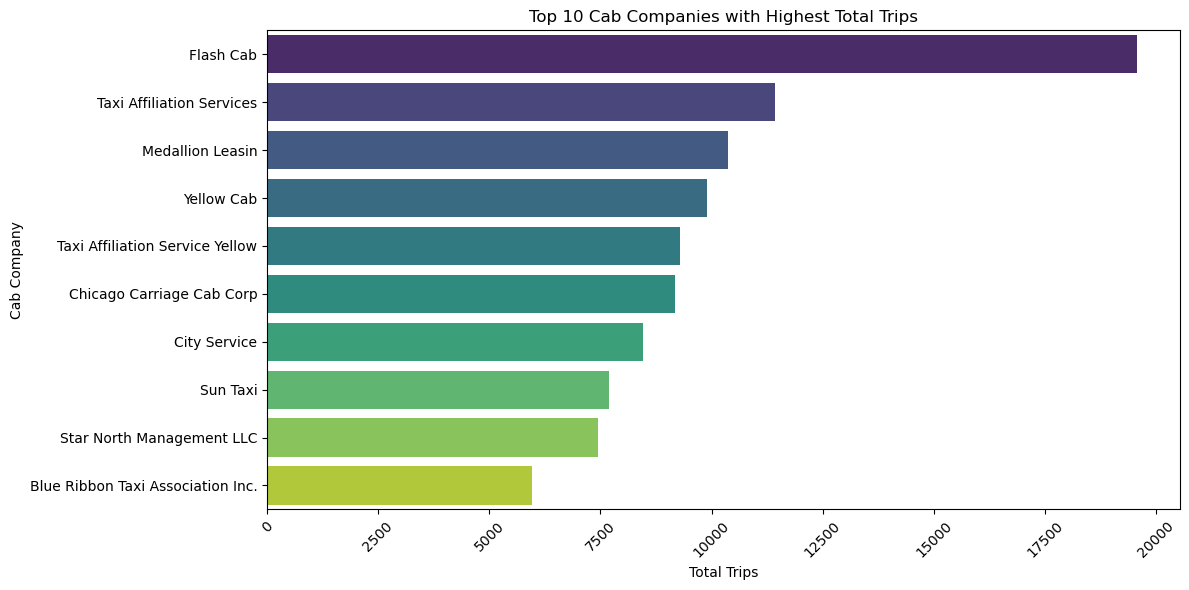

In [104]:
# Plotting the top 10 cab companies with the  trips
plt.figure(figsize=(12, 6))
sns.barplot(x='trips_amount', y='company_name', data=df_cab_company.head(10), palette='viridis')
plt.title('Top 10 Cab Companies with Highest Total Trips')
plt.xlabel('Total Trips')
plt.ylabel('Cab Company')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

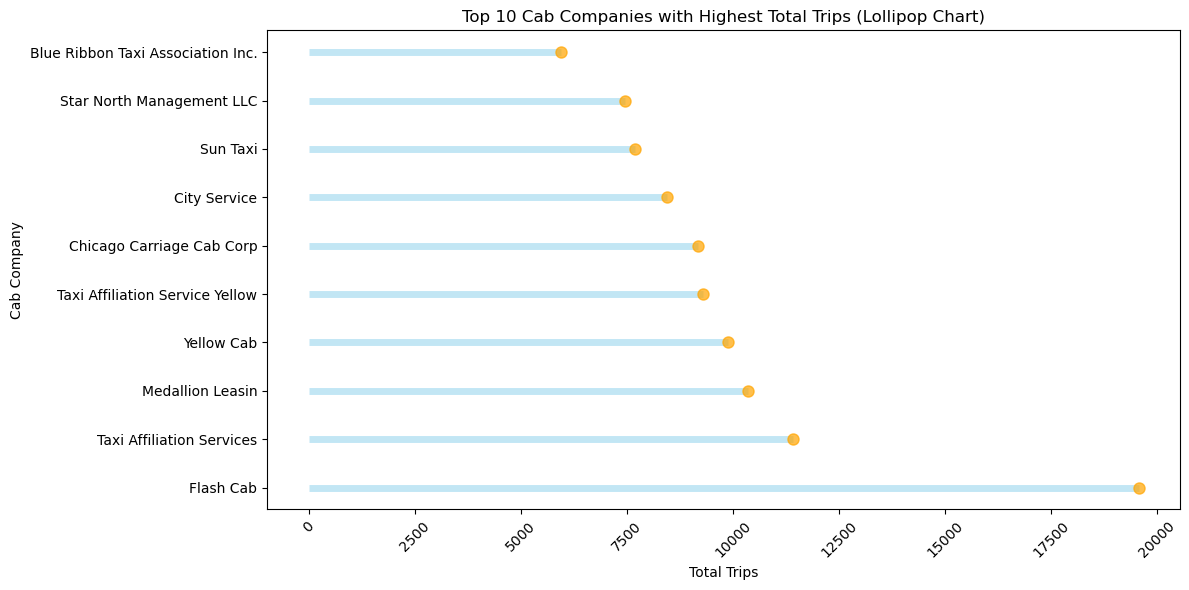

In [105]:
# horizontal lollipop chart for the top 10 cab companies with the highest total trips
plt.figure(figsize=(12, 6))
plt.hlines(y=df_cab_company['company_name'].head(10), xmin=0, xmax=df_cab_company['trips_amount'].head(10), color='skyblue', alpha=0.5, linewidth=5)
plt.plot(df_cab_company['trips_amount'].head(10), df_cab_company['company_name'].head(10), "o", color='orange', markersize=8, alpha=0.7)
plt.title('Top 10 Cab Companies with Highest Total Trips (Lollipop Chart)')
plt.xlabel('Total Trips')
plt.ylabel('Cab Company')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>📊
<ul>
  <li>Flash Cab leads significantly</li>
  <li>After Flash Cab there is a gradual decline amount the remaning 2-10</li>
  
</ul></div>

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Make a graph for the 10 cab dropoff locations</b>

</div>

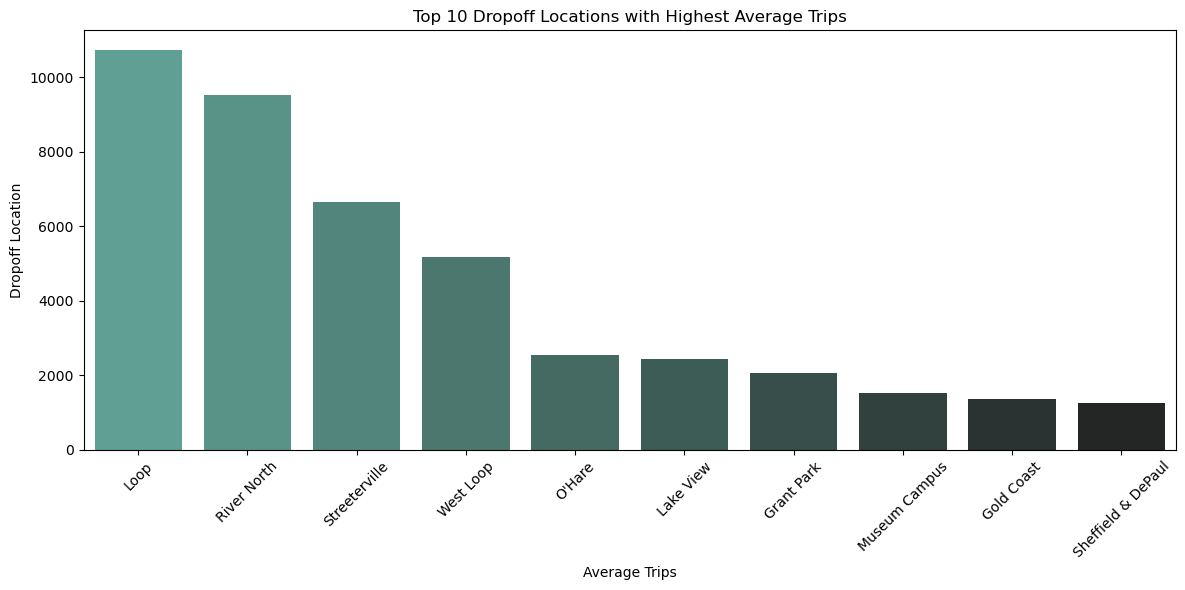

In [106]:
# Plotting the top 10 dropoff locations 
plt.figure(figsize=(12, 6))
sns.barplot(x='dropoff_location_name', y='average_trips', data=df_trips_sorted.head(10), palette="dark:#5A9_r")
plt.title('Top 10 Dropoff Locations with Highest Average Trips')
plt.xlabel('Average Trips') 
plt.ylabel('Dropoff Location')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


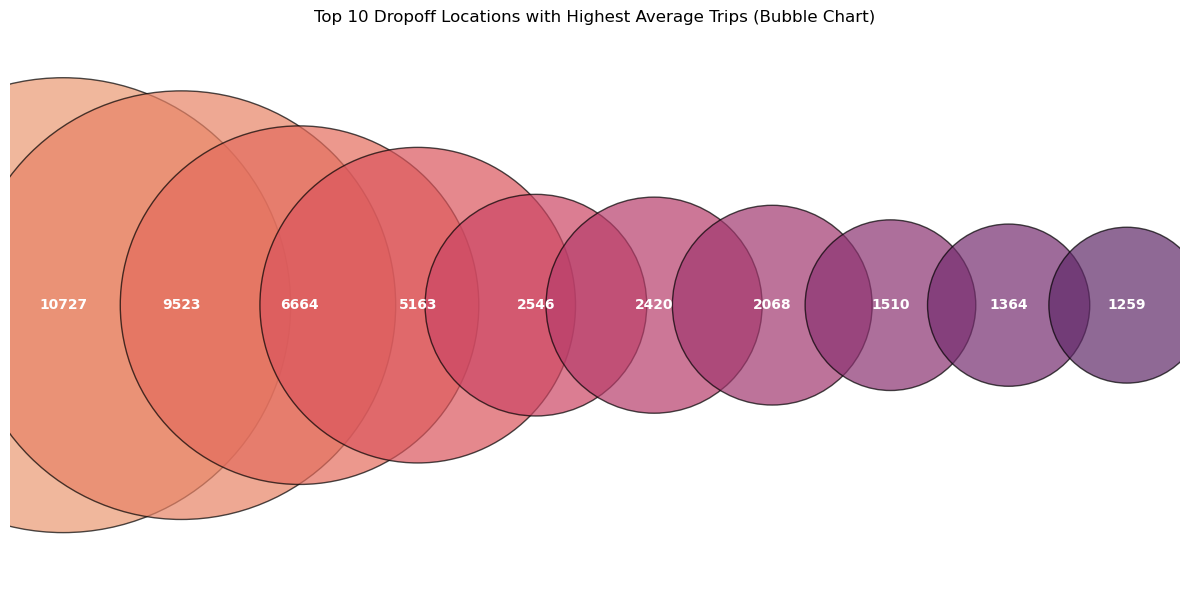

In [107]:
plt.figure(figsize=(12, 6))

# Bubble chart with size proportional to average trips
plt.scatter(
    x=df_trips_sorted.head(10)['dropoff_location_name'],
    y=[1]*10,  # dummy y to align bubbles horizontally
    s=df_trips_sorted.head(10)['average_trips'] * 10,  # scale as needed
    c=sns.color_palette("flare", 10),
    alpha=0.7,
    edgecolors='black'
)

# Add labels inside bubbles
for i, row in df_trips_sorted.head(10).iterrows():
    plt.text(
        x=row['dropoff_location_name'], 
        y=1, 
        s=int(row['average_trips']), 
        ha='center', 
        va='center', 
        color='white',
        fontsize=10,
        weight='bold'
    )

plt.title('Top 10 Dropoff Locations with Highest Average Trips (Bubble Chart)')
plt.axis('off')
plt.tight_layout()
plt.show()

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>📊
<ul>
  <li>The previous two graphs show that Loop and River North are the clear leaders while Loop has a slight edge over River North.</li>
  <li>After those there is a steep drop off after the top 2-3</li>
  <li>he bottom five locations are relatively balanced</li>
  
</ul></div>

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Importing Loop --> O'hare Dataset</b>

</div>

In [108]:
df_loop_ohare = pd.read_csv('loop_ohare.csv')

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Preliminary analysis of Loop to Ohare dataset</b>

</div>

In [109]:
df_loop_ohare.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [110]:
df_loop_ohare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Confirming Proper data types ... converting start_ts object to datetime</b>

</div>

In [111]:
# Converting start_ts to datetime 
df_loop_ohare['start_ts'] = pd.to_datetime(df_loop_ohare['start_ts'])

In [112]:
df_loop_ohare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️Checking for missing values and duplicates</b>

</div>

In [113]:
df_loop_ohare.duplicated().sum()

197

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️There appears to be a lot of duplicates</b>

</div>

In [114]:
df_loop_ohare.groupby(['start_ts', 'weather_conditions', 'duration_seconds']).size().reset_index(name='count').query('count > 1')


,start_ts,weather_conditions,duration_seconds,count
9,2017-11-04 05:00:00,Good,1200.0,2
24,2017-11-04 06:00:00,Good,1267.0,2
41,2017-11-04 07:00:00,Good,1140.0,2
42,2017-11-04 07:00:00,Good,1200.0,2
43,2017-11-04 07:00:00,Good,1260.0,2
...,...,...,...,...
754,2017-11-18 15:00:00,Good,3240.0,2
762,2017-11-18 16:00:00,Bad,2820.0,2
816,2017-11-25 11:00:00,Good,1680.0,2
821,2017-11-25 12:00:00,Good,1380.0,2


In [115]:
dupes = (
    df_loop_ohare
    .groupby(['start_ts', 'weather_conditions', 'duration_seconds'])
    .size()
    .reset_index(name='count')
    .query('count > 1')
)
df_loop_ohare_duplicated = df_loop_ohare.merge(
    dupes.drop(columns='count'),
    on=['start_ts', 'weather_conditions', 'duration_seconds'],
    how='inner'
)
df_loop_ohare_duplicated.head(10)

,start_ts,weather_conditions,duration_seconds
0,2017-11-11 07:00:00,Good,1440.0
1,2017-11-11 07:00:00,Good,1440.0
2,2017-11-11 07:00:00,Good,1440.0
3,2017-11-11 07:00:00,Good,1440.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 14:00:00,Good,2460.0
6,2017-11-11 14:00:00,Good,2460.0
7,2017-11-18 06:00:00,Good,1500.0
8,2017-11-18 06:00:00,Good,1500.0
9,2017-11-18 06:00:00,Good,1500.0


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️After further investigation there is a lot of completely duplicate rows so because it takes about %20 of the dataset I'm going to drop the duplicates</b>

</div>

In [116]:
df_loop_ohare.drop_duplicates(subset=['start_ts', 'weather_conditions', 'duration_seconds'], keep='first', inplace=True)
df_loop_ohare.reset_index(drop=True, inplace=True)
df_loop_ohare.duplicated().sum()

0

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ After cleaning up the dataset I'm ready to start testing the hypothesis that the Loop to O'hare International Airport changes on rainy saturdays</b>

</div>

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ I'm going to compare rainy saturdays to non-rainy saturdays so the data isn't skewed towards the rest of the days of the week</b>

</div>

In [117]:
df_loop_ohare['day_of_week'] = df_loop_ohare['start_ts'].dt.day_name()
# Keeping only saturday
df_loop_ohare_saturday = df_loop_ohare[df_loop_ohare['day_of_week'] == 'Saturday']
df_loop_ohare_saturday.head()

,start_ts,weather_conditions,duration_seconds,day_of_week
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ I'm going to first just find the mean duration_seconds of Good vs Bad days to get an idea of the data before I run a Hypothesis test</b>

</div>

In [118]:
avg_duration = df_loop_ohare_saturday.groupby('weather_conditions')['duration_seconds'].mean().reset_index()
print(avg_duration)

  weather_conditions  duration_seconds
0                Bad       2409.229730
1               Good       2032.253112


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ The mean is nearly 400 seconds more but I will run a Null hypothesis test to see how great the change is </b>

</div>


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ How I formed the Null Hypothesis</b>
<ul>
  <li>Null Hypothesis: The average ride duration from the Loop to O’Hare on rainy Saturdays is equal to the average duration on non-rainy (sunny) Saturdays.</li>

  <li> Alternative Hypothesis: The average ride duration on rainy Saturdays is different from that on sunny Saturdays.</li>

  <li>I chose the default alpha of 0.05 to accept a 5% risk of incorrectly rejecting the null hypothesis</li>

  <li>If: p-value < 0.05 we Reject the null hypothesis: There is a statistically significant difference in average ride durations.</li>
  
  <li>If: p-value ≥ 0.05 we Fail to reject the null: No significant evidence of a difference.</li>
</ul>
</div>

In [119]:
rainy = df_loop_ohare_saturday[df_loop_ohare_saturday['weather_conditions'] == 'Bad']['duration_seconds']
sunny = df_loop_ohare_saturday[df_loop_ohare_saturday['weather_conditions'] == 'Good']['duration_seconds']

t_stat, p_value = ttest_ind(rainy, sunny, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")



T-statistic: 5.531968188074177, P-value: 9.126383933880083e-08


<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ With a P-value of 0.00000000912 It's clear there is a large statistical difference between the rainy and non-rainy days... The T-stat of 5.53 also confirms that there is a strong difference between the two. We can confidently reject the null hypthesis.</b>

</div>

<div style="padding:10px; background:#e6f7ff; border-left:5px solid #1890ff; border-radius:5px; color:black;">
<b>ℹ️ Graph showing the average durations of rainy and non-rainy days</b>

</div>

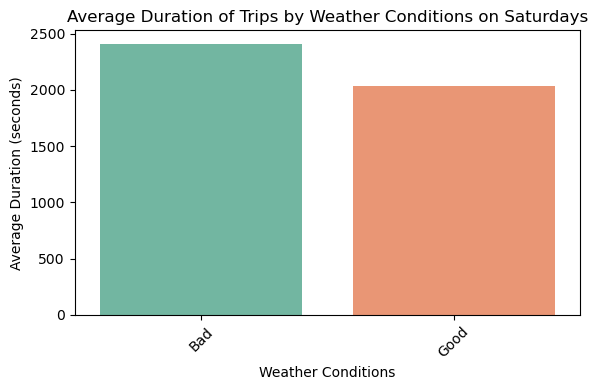

In [120]:
# Plotting the average duration for each weather condition
plt.figure(figsize=(6, 4))
sns.barplot(x='weather_conditions', y='duration_seconds', data=avg_duration, palette='Set2')
plt.title('Average Duration of Trips by Weather Conditions on Saturdays')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()